# Clustering de Acciones del IPC (Indice de Precios y Cotizaciones)

## Objetivo

Se cuenta con el histórico de precios de **29 acciones** que cotizan en la Bolsa Mexicana de Valores (BMV) y que forman parte del IPC.

Para cada acción se calcularán **9 métricas financieras** que resumen su comportamiento. Esto nos dejará una tabla de 29 renglones (acciones) y 9 columnas (métricas).

Con esa tabla, se aplicarán **tres algoritmos de clustering** (K-Means, DBSCAN y Clustering Jerárquico) para intentar agrupar las acciones que se comportan de manera similar.

Finalmente, se analizará si la **ventana de tiempo** de observación tiene algún efecto en los agrupamientos.

## ¿Qué es el IPC?

El IPC (Índice de Precios y Cotizaciones) es el principal indicador de la Bolsa Mexicana de Valores. Agrupa a las empresas más grandes y líquidas del mercado mexicano. Es el equivalente mexicano del S&P 500 en Estados Unidos.

## Paso 0: Instalación de librerías

En Google Colab, la mayoría de las librerías de ciencia de datos ya están preinstaladas (pandas, numpy, sklearn, matplotlib, seaborn). Sin embargo, `yfinance` **no viene preinstalada** y se necesita instalar manualmente.

`yfinance` es una librería de Python que permite descargar datos financieros históricos (precios, volúmenes, dividendos, etc.) directamente desde Yahoo Finance de manera gratuita y programática.

In [95]:
# Se instala yfinance desde PyPI (el repositorio público de paquetes de Python)
# El signo de exclamación (!) indica que se ejecuta un comando de terminal, no de Python
# La bandera -q significa "quiet", para que no muestre tanta información durante la instalación
!pip install -q yfinance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Paso 1: Importación de librerías

Cada librería tiene un propósito específico:

| Librería | Alias | ¿Para qué sirve? |
|----------|-------|-------------------|
| `pandas` | `pd` | Manipulación y análisis de datos tabulares (DataFrames). Es la columna vertebral de todo análisis de datos en Python. |
| `numpy` | `np` | Operaciones numéricas eficientes sobre arreglos (vectores y matrices). Muchas funciones de pandas y sklearn la usan internamente. |
| `matplotlib.pyplot` | `plt` | Creación de gráficas estáticas (líneas, barras, scatter, etc.). Es la librería de visualización más fundamental. |
| `seaborn` | `sns` | Visualización estadística de alto nivel. Construida sobre matplotlib, facilita crear gráficas más bonitas y complejas con menos código. |
| `yfinance` | `yf` | Descarga de datos financieros históricos desde Yahoo Finance (precios, volúmenes, dividendos). |
| `scipy.stats` | `stats` | Funciones estadísticas avanzadas. La usaremos para calcular skewness (asimetría) y kurtosis (curtosis). |
| `StandardScaler` | — | Estandariza las variables para que tengan media 0 y desviación estándar 1. Fundamental antes de aplicar algoritmos basados en distancias. |
| `KMeans` | — | Algoritmo de clustering que agrupa datos en K grupos minimizando la distancia al centroide de cada grupo. |
| `DBSCAN` | — | Algoritmo de clustering basado en densidad. No requiere especificar el número de clusters. Puede detectar outliers. |
| `AgglomerativeClustering` | — | Clustering jerárquico. Construye una jerarquía de clusters fusionando los más cercanos iterativamente. |
| `metrics` | — | Módulo de sklearn con métricas para evaluar la calidad de los clusters (Silueta, Calinski-Harabasz, Davies-Bouldin). |
| `PCA` | — | Análisis de Componentes Principales. Reduce la dimensionalidad de los datos conservando la mayor variabilidad posible. Lo usaremos para visualizar 9 dimensiones en 2D. |
| `dendrogram`, `linkage` | — | Funciones de scipy para construir y visualizar dendrogramas (árboles jerárquicos de clusters). |

In [96]:
# ============================================================================
# LIBRERÍAS BASE: manipulación de datos y operaciones numéricas
# ============================================================================
import pandas as pd        # Para trabajar con tablas de datos (DataFrames)
import numpy as np         # Para operaciones matemáticas sobre arreglos numéricos

# ============================================================================
# LIBRERÍAS DE VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt   # Para crear gráficas estáticas (scatter, líneas, barras)
import seaborn as sns              # Para visualizaciones estadísticas más elegantes

# ============================================================================
# LIBRERÍA PARA DESCARGAR DATOS FINANCIEROS
# ============================================================================
import yfinance as yf   # Para descargar precios históricos de acciones desde Yahoo Finance

# ============================================================================
# LIBRERÍA DE ESTADÍSTICA
# ============================================================================
from scipy import stats  # Para funciones estadísticas avanzadas (skewness, kurtosis)

# ============================================================================
# PREPROCESAMIENTO DE DATOS (sklearn)
# ============================================================================
# StandardScaler transforma las variables para que tengan media = 0 y desviación estándar = 1
# Esto es FUNDAMENTAL para clustering porque los algoritmos calculan distancias
# Si no escalamos, las variables con magnitudes grandes dominan el resultado
from sklearn.preprocessing import StandardScaler

# ============================================================================
# ALGORITMOS DE CLUSTERING (sklearn)
# ============================================================================
from sklearn.cluster import KMeans                  # Clustering por k-medias
from sklearn.cluster import DBSCAN                  # Clustering basado en densidad
from sklearn.cluster import AgglomerativeClustering  # Clustering jerárquico

# ============================================================================
# MÉTRICAS DE EVALUACIÓN DE CLUSTERS (sklearn)
# ============================================================================
# Estas métricas nos ayudan a evaluar "qué tan buenos" son los clusters formados
from sklearn import metrics

# ============================================================================
# REDUCCIÓN DE DIMENSIONALIDAD (sklearn)
# ============================================================================
# PCA nos permite pasar de 9 variables a 2, para poder graficar los clusters en 2D
from sklearn.decomposition import PCA

# ============================================================================
# DENDROGRAMA (scipy)
# ============================================================================
# Para visualizar la jerarquía de clusters en forma de árbol
from scipy.cluster.hierarchy import dendrogram, linkage

## Paso 2: Descarga de datos financieros

Se descargarán los precios históricos de las 29 acciones del IPC usando `yfinance`.

**¿Qué datos descarga `yf.download`?** Para cada acción y cada día de operación bursátil, se obtienen las siguientes columnas:

| Columna | Significado |
|---------|-------------|
| `Open` | Precio al que abrió la acción ese día (primer precio del día) |
| `High` | Precio máximo alcanzado durante el día |
| `Low` | Precio mínimo alcanzado durante el día |
| `Close` | Precio al que cerró la acción ese día (último precio del día) |
| `Volume` | Número total de acciones que se compraron/vendieron ese día |

**Parámetros importantes:**
- `start` y `end`: Definen la ventana temporal de observación
- `group_by='ticker'`: Organiza los datos por acción (cada acción tiene sus propias columnas de Open, High, Low, Close, Volume)
- `auto_adjust=True`: Ajusta automáticamente los precios por splits y dividendos, para que los precios sean comparables a lo largo del tiempo

In [97]:
# Se define la lista de tickers (símbolos bursátiles) de las 29 acciones del IPC
# Cada ticker termina en ".MX" porque cotizan en la Bolsa Mexicana de Valores
# Por ejemplo: "WALMEX.MX" es Walmart de México, "BIMBOA.MX" es Grupo Bimbo
lista_tickers_ipc = [
    "AC.MX", "ALPEKA.MX", "ALSEA.MX", "AMXB.MX", "ASURB.MX",
    "BBAJIOO.MX", "BIMBOA.MX", "BOLSAA.MX", "CEMEXCPO.MX", "CHDRAUIB.MX",
    "CUERVO.MX", "ELEKTRA.MX", "FEMSAUBD.MX", "GAPB.MX", "GCARSOA1.MX",
    "GCC.MX", "GENTERA.MX", "GFNORTEO.MX", "GNP.MX",
    "GRUMAB.MX", "ORBIA.MX", "PE&OLES.MX", "PINFRA.MX", "Q.MX",
    "RA.MX", "TLEVISACPO.MX", "VESTA.MX", "VOLARA.MX",
    "WALMEX.MX"
]

# Se define la ventana temporal de observación
# Desde el 1 de enero de 2022 hasta el 31 de marzo de 2026
fecha_inicio = "2022-01-01"
fecha_final = "2026-03-31"

# Se descargan los datos usando yfinance
# group_by='ticker': agrupa las columnas por acción
# auto_adjust=True: ajusta precios por splits y dividendos
# progress=False: no muestra la barra de progreso para que el output quede más limpio
datos = yf.download(
    lista_tickers_ipc,
    start=fecha_inicio,
    end=fecha_final,
    group_by='ticker',
    auto_adjust=True,
    progress=False
)

# Se muestran las dimensiones del DataFrame descargado
# Tendrá muchos renglones (uno por cada día bursátil) y muchas columnas (5 por cada acción)
print(f"Dimensiones del DataFrame descargado: {datos.shape}")
print(f"Número de días bursátiles: {datos.shape[0]}")
print(f"Número de columnas: {datos.shape[1]} (5 columnas x {len(lista_tickers_ipc)} acciones = {5 * len(lista_tickers_ipc)})")

$ELEKTRA.MX: possibly delisted; no timezone found

1 Failed download:
['ELEKTRA.MX']: possibly delisted; no timezone found


Dimensiones del DataFrame descargado: (1065, 146)
Número de días bursátiles: 1065
Número de columnas: 146 (5 columnas x 29 acciones = 145)


In [98]:
# Se visualizan las primeras filas del DataFrame descargado
# Se verá una estructura de MultiIndex en las columnas: (Ticker, Métrica)
# Por ejemplo: (AC.MX, Close), (AC.MX, High), etc.
datos.head()

Ticker     ELEKTRA.MX                                    ASURB.MX              \
Price            Open High Low Close Adj Close Volume        Open        High   
Date                                                                            
2022-01-03        NaN  NaN NaN   NaN       NaN    NaN  330.159143  331.978228   
2022-01-04        NaN  NaN NaN   NaN       NaN    NaN  331.250621  331.250621   
2022-01-05        NaN  NaN NaN   NaN       NaN    NaN  328.835504  333.627040   
2022-01-06        NaN  NaN NaN   NaN       NaN    NaN  328.494909  337.729638   
2022-01-07        NaN  NaN NaN   NaN       NaN    NaN  334.509469  338.588844   

Ticker                              ...  BOLSAA.MX                        \
Price              Low       Close  ...       Open       High        Low   
Date                                ...                                    
2022-01-03  323.641431  326.768707  ...  29.523016  29.921974  28.792843   
2022-01-04  325.894024  328.038208  ...  29.650981  29.778950  28.604653   
2022-01-05  325.739197  330.290771  ...  28.792846  28.958453  28.002455   
2022-01-06  326.188176  336.367279  ...  28.348719  28.898230  28.348719   
2022-01-07  328.982551  332.814240  ...  28.529385  28.694989  28.092786   

Ticker                              GNP.MX                          \
Price           Close   Volume        Open        High         Low   
Date                                                                 
2022-01-03  29.312243  1089100  105.430336  105.430336  105.430336   
2022-01-04  28.770260   659836  105.430336  105.430336  105.430336   
2022-01-05  28.243336  3140792  105.430336  105.430336  105.430336   
2022-01-06  28.461634   677741  105.430336  105.430336  105.430336   
2022-01-07  28.190645   222050  104.578400  104.578400  104.578400   

Ticker                         
Price            Close Volume  
Date                           
2022-01-03  105.430336      0  
2022-01-04  105.430336      0  
2022-01-05  105.430336      0  
2022-01-06  105.430336      0  
2022-01-07  104.578400    321  

[5 rows x 146 columns]

## Paso 3: Cálculo de las 9 métricas financieras por acción

Para cada una de las 29 acciones se calculará un resumen de 9 números. Estas métricas capturan diferentes aspectos del comportamiento de la acción:

### ¿Qué significa cada métrica?

1. **Volumen promedio**: Promedio del número de acciones negociadas por día. Un volumen alto indica que la acción es muy líquida (fácil de comprar y vender).

2. **Rendimiento diario promedio**: El rendimiento diario se calcula como el cambio porcentual del precio de cierre de un día respecto al anterior:
$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$
El promedio nos dice si la acción tiende a subir o bajar en general.

3. **Volatilidad del rendimiento diario**: Es la desviación estándar de los rendimientos diarios. Mide qué tanto "se mueve" el precio día a día. Una volatilidad alta significa que el precio fluctúa mucho (más riesgo, pero potencialmente más ganancia).

4. **Skewness (asimetría) del rendimiento diario**: Mide si la distribución de rendimientos está "chueca" hacia un lado.
   - Skewness > 0: Hay más días con rendimientos extremos positivos (colas a la derecha)
   - Skewness < 0: Hay más días con rendimientos extremos negativos (colas a la izquierda)
   - Skewness ≈ 0: La distribución es aproximadamente simétrica

5. **Curtosis del rendimiento diario**: Mide qué tan "puntiaguda" o "achatada" es la distribución de rendimientos respecto a una distribución normal.
   - Curtosis > 0 (leptocúrtica): Colas más pesadas, más eventos extremos de lo esperado
   - Curtosis < 0 (platicúrtica): Colas más ligeras, menos eventos extremos
   - Curtosis ≈ 0 (mesocúrtica): Similar a una distribución normal

6. **Sharpe Ratio**: Mide el rendimiento ajustado por riesgo. Se calcula como:
$$\text{Sharpe} = \frac{\bar{r}}{\sigma_r}$$
donde $\bar{r}$ es el rendimiento promedio y $\sigma_r$ es la volatilidad. Un Sharpe alto indica que la acción da buen rendimiento por unidad de riesgo asumido.

7. **Rango intradía promedio**: Promedio de la diferencia entre el precio máximo y mínimo de cada día, expresado como porcentaje del precio de cierre:
$$\text{Rango intradía}_t = \frac{High_t - Low_t}{Close_t}$$
Captura cuánto se mueve el precio *dentro* de cada día de operación.

8. **Rango horario promedio**: Promedio de la diferencia entre el precio de cierre y el de apertura, como porcentaje del precio de apertura:
$$\text{Rango horario}_t = \frac{Close_t - Open_t}{Open_t}$$
Captura la dirección intradía: ¿el precio tiende a subir o bajar durante el día?

9. **Up/Down Volume Ratio**: Suma del volumen en días alcistas (precio subió) dividida entre la suma del volumen en días bajistas (precio bajó):
$$\text{Up/Down} = \frac{\sum \text{Volumen en días con } r_t > 0}{\sum \text{Volumen en días con } r_t < 0}$$
Un ratio > 1 indica que se negocia más volumen cuando el precio sube (sentimiento optimista).

In [99]:
# Se define una función que, dada la tabla de datos descargada y un ticker específico,
# calcula las 9 métricas financieras y las devuelve como un diccionario.
#
# ¿Por qué una función? Porque se necesita repetir exactamente el mismo cálculo
# para cada una de las 29 acciones. En lugar de copiar y pegar el código 29 veces,
# se encapsula la lógica en una función que se llama dentro de un ciclo.

def calcular_metricas(datos, ticker):
    """
    Calcula las 9 métricas financieras para una acción específica.

    Parámetros:
    - datos: DataFrame descargado con yfinance (MultiIndex en columnas)
    - ticker: string con el símbolo bursátil (ej. "WALMEX.MX")

    Retorna:
    - Diccionario con las 9 métricas
    """

    # Se extraen las columnas de esta acción específica
    # datos[ticker] devuelve un DataFrame con columnas: Close, High, Low, Open, Volume
    df_accion = datos[ticker].dropna()

    # -------------------------------------------------------------------------
    # Se extraen las series de precios y volumen
    # Cada una es un vector (pandas Series) con un valor por cada día
    # -------------------------------------------------------------------------
    close  = df_accion['Close']    # Precio de cierre de cada día
    high   = df_accion['High']     # Precio máximo de cada día
    low    = df_accion['Low']      # Precio mínimo de cada día
    open_  = df_accion['Open']     # Precio de apertura de cada día (open_ con guión bajo porque "open" es palabra reservada de Python)
    volume = df_accion['Volume']   # Volumen de cada día

    # -------------------------------------------------------------------------
    # MÉTRICA 1: Volumen promedio
    # Se calcula el promedio aritmético del volumen diario
    # -------------------------------------------------------------------------
    volumen_promedio = volume.mean()

    # -------------------------------------------------------------------------
    # MÉTRICA 2: Rendimiento diario promedio
    # pct_change() calcula el cambio porcentual entre cada día y el anterior:
    #   rendimiento_t = (close_t - close_{t-1}) / close_{t-1}
    # dropna() elimina el primer valor que es NaN (no hay día anterior para el primer dato)
    # -------------------------------------------------------------------------
    rendimientos = close.pct_change().dropna()
    rendimiento_promedio = rendimientos.mean()

    # -------------------------------------------------------------------------
    # MÉTRICA 3: Volatilidad del rendimiento diario
    # Es la desviación estándar de los rendimientos diarios
    # Mide la dispersión: si es alta, el precio se mueve mucho día a día
    # -------------------------------------------------------------------------
    volatilidad = rendimientos.std()

    # -------------------------------------------------------------------------
    # MÉTRICA 4: Skewness (asimetría) del rendimiento diario
    # Se usa el método .skew() de pandas que calcula el coeficiente de asimetría
    # Un valor positivo indica que hay más rendimientos extremos positivos
    # Un valor negativo indica que hay más rendimientos extremos negativos
    # -------------------------------------------------------------------------
    skewness = rendimientos.skew()

    # -------------------------------------------------------------------------
    # MÉTRICA 5: Curtosis del rendimiento diario
    # Se usa el método .kurtosis() de pandas que calcula la curtosis en exceso
    # Un valor > 0 indica colas pesadas (más eventos extremos de lo esperado)
    # -------------------------------------------------------------------------
    curtosis = rendimientos.kurtosis()

    # -------------------------------------------------------------------------
    # MÉTRICA 6: Sharpe Ratio
    # Rendimiento promedio dividido entre la volatilidad
    # Mide cuánto rendimiento se obtiene por cada unidad de riesgo
    # Sharpe alto = buen negocio (mucho rendimiento, poco riesgo)
    # Sharpe bajo = mal negocio (poco rendimiento, mucho riesgo)
    # -------------------------------------------------------------------------
    sharpe_ratio = rendimiento_promedio / volatilidad if volatilidad > 0 else 0

    # -------------------------------------------------------------------------
    # MÉTRICA 7: Rango intradía promedio
    # Para cada día: (máximo - mínimo) / cierre
    # Esto da un porcentaje que indica cuánto fluctuó el precio dentro del día
    # Luego se promedia sobre todos los días
    # -------------------------------------------------------------------------
    rango_intradia = ((high - low) / close).mean()

    # -------------------------------------------------------------------------
    # MÉTRICA 8: Rango horario promedio
    # Para cada día: (cierre - apertura) / apertura
    # Indica si durante el día el precio tendió a subir (positivo) o bajar (negativo)
    # Luego se promedia sobre todos los días
    # -------------------------------------------------------------------------
    rango_horario = ((close - open_) / open_).mean()

    # -------------------------------------------------------------------------
    # MÉTRICA 9: Up/Down Volume Ratio
    # Se identifica cuáles días fueron alcistas (rendimiento > 0) y cuáles bajistas (rendimiento < 0)
    # Se suma el volumen de los días alcistas y se divide entre el volumen de los días bajistas
    # Un ratio > 1 indica sentimiento optimista (más compras cuando sube)
    # -------------------------------------------------------------------------
    # Se alinean los rendimientos con el volumen (tienen la misma longitud tras dropna)
    vol_alineado = volume.iloc[1:]  # Se quita el primer día porque rendimientos empieza desde el segundo

    # Se separa el volumen en días alcistas y bajistas
    volumen_alcista = vol_alineado[rendimientos.values > 0].sum()
    volumen_bajista = vol_alineado[rendimientos.values < 0].sum()

    # Se calcula el ratio (se protege contra división por cero)
    up_down_ratio = volumen_alcista / volumen_bajista if volumen_bajista > 0 else np.nan

    # Se devuelve un diccionario con las 9 métricas
    return {
        'ticker': ticker.replace('.MX', ''),  # Se quita el ".MX" para que los nombres queden más limpios
        'volumen_promedio': volumen_promedio,
        'rendimiento_promedio': rendimiento_promedio,
        'volatilidad': volatilidad,
        'skewness': skewness,
        'curtosis': curtosis,
        'sharpe_ratio': sharpe_ratio,
        'rango_intradia': rango_intradia,
        'rango_horario': rango_horario,
        'up_down_ratio': up_down_ratio
    }

In [100]:
# Se aplica la función a cada una de las 29 acciones
# Se recorre la lista de tickers y se almacenan los resultados en una lista de diccionarios
resultados = []
for ticker in lista_tickers_ipc:
    try:
        metricas = calcular_metricas(datos, ticker)
        resultados.append(metricas)
    except Exception as e:
        # Si alguna acción falla (por ejemplo, porque no tiene datos suficientes),
        # se imprime un mensaje de advertencia y se continúa con la siguiente
        print(f"No se pudo procesar {ticker}: {e}")

# Se convierte la lista de diccionarios en un DataFrame
# Cada renglón es una acción, cada columna es una métrica
df_metricas = pd.DataFrame(resultados)

# Se establece el ticker como índice del DataFrame
# Esto facilita la lectura: cada renglón se identifica por el nombre de la acción
df_metricas = df_metricas.set_index('ticker')

# Se verifica cuántas acciones se procesaron exitosamente
print(f"Se procesaron {df_metricas.shape[0]} acciones con {df_metricas.shape[1]} métricas cada una")

Se procesaron 29 acciones con 9 métricas cada una


In [101]:
# Se muestra la tabla completa de métricas
# Esta es la tabla clave del análisis: 29 acciones x 9 métricas
df_metricas

,volumen_promedio,rendimiento_promedio,volatilidad,skewness,curtosis,sharpe_ratio,rango_intradia,rango_horario,up_down_ratio
ticker,,,,,,,,,
AC,1.775127e+06,0.000693,0.015015,0.282925,1.987930,0.046158,0.025593,0.000689,1.264799
ALPEKA,1.642607e+06,-0.000331,0.024150,0.018682,6.289806,-0.013696,0.035928,-0.000932,1.029902
ALSEA,1.653428e+06,0.000546,0.019049,0.364100,4.753441,0.028681,0.029982,0.000595,1.174352
AMXB,4.031130e+07,0.000292,0.014936,-1.720141,24.254245,0.019576,0.014200,-0.000057,0.854889
ASURB,4.630819e+05,0.000731,0.018993,1.726506,35.672576,0.038509,0.028926,-0.000152,1.072193
BBAJIOO,2.518443e+06,0.000958,0.019991,0.051738,2.111758,0.047921,0.032560,-0.000354,1.260403
BIMBOA,2.328501e+06,0.000207,0.019648,0.256641,1.724352,0.010544,0.031348,-0.000252,0.955150
BOLSAA,1.346566e+06,0.000321,0.017173,0.032729,3.329466,0.018678,0.028692,-0.001328,0.989100
CEMEXCPO,3.900601e+07,0.000582,0.022221,0.338794,2.462322,0.026191,0.031151,0.000669,1.078991


In [102]:
# Se muestran las estadísticas descriptivas de las métricas
# Esto nos permite entender la escala y distribución de cada columna
# OBSERVACIÓN IMPORTANTE: Nótese cómo el volumen promedio está en millones
# mientras que el rendimiento promedio está en fracciones cercanas a 0
# Esto justifica la necesidad de escalar las variables antes de hacer clustering
df_metricas.describe()

,volumen_promedio,rendimiento_promedio,volatilidad,skewness,curtosis,sharpe_ratio,rango_intradia,rango_horario,up_down_ratio
count,2.800000e+01,28.000000,28.000000,28.000000,28.000000,29.000000,28.000000,28.000000,28.000000
mean,5.073486e+06,0.000455,0.019932,-0.123423,13.281753,0.023356,0.029930,0.000033,1.040809
std,1.039509e+07,0.000628,0.004841,1.628825,40.734059,0.027829,0.008464,0.000844,0.163199
min,1.010854e+03,-0.000833,0.009277,-7.982987,0.994185,-0.040555,0.000497,-0.001858,0.463847
25%,5.673933e+05,0.000185,0.016321,0.007760,1.963674,0.010544,0.026888,-0.000277,0.967607
50%,1.714278e+06,0.000535,0.019780,0.153333,2.536012,0.028681,0.030472,0.000204,1.037483
75%,2.744520e+06,0.000833,0.022306,0.309076,5.553741,0.043198,0.033272,0.000650,1.148367
max,4.031130e+07,0.001638,0.031338,1.726506,217.408706,0.070470,0.044157,0.001793,1.272771


In [103]:
# Se revisa si hay valores NaN en las métricas calculadas
# Esto puede pasar si alguna acción no tuvo datos suficientes o si hubo división por cero
print("Valores NaN por columna:")
print(df_metricas.isna().sum())
print(f"\nAcciones con al menos un NaN:")
print(df_metricas[df_metricas.isna().any(axis=1)])

Valores NaN por columna:
volumen_promedio        1
rendimiento_promedio    1
volatilidad             1
skewness                1
curtosis                1
sharpe_ratio            0
rango_intradia          1
rango_horario           1
up_down_ratio           1
dtype: int64

Acciones con al menos un NaN:
         volumen_promedio  rendimiento_promedio  volatilidad  skewness  \
ticker                                                                   
ELEKTRA               NaN                   NaN          NaN       NaN   

         curtosis  sharpe_ratio  rango_intradia  rango_horario  up_down_ratio  
ticker                                                                         
ELEKTRA       NaN           0.0             NaN            NaN            NaN  


## Paso 4: Exploración visual de las métricas

Antes de aplicar clustering, es buena práctica explorar visualmente los datos para entender la estructura de correlación entre las métricas y detectar posibles patrones.

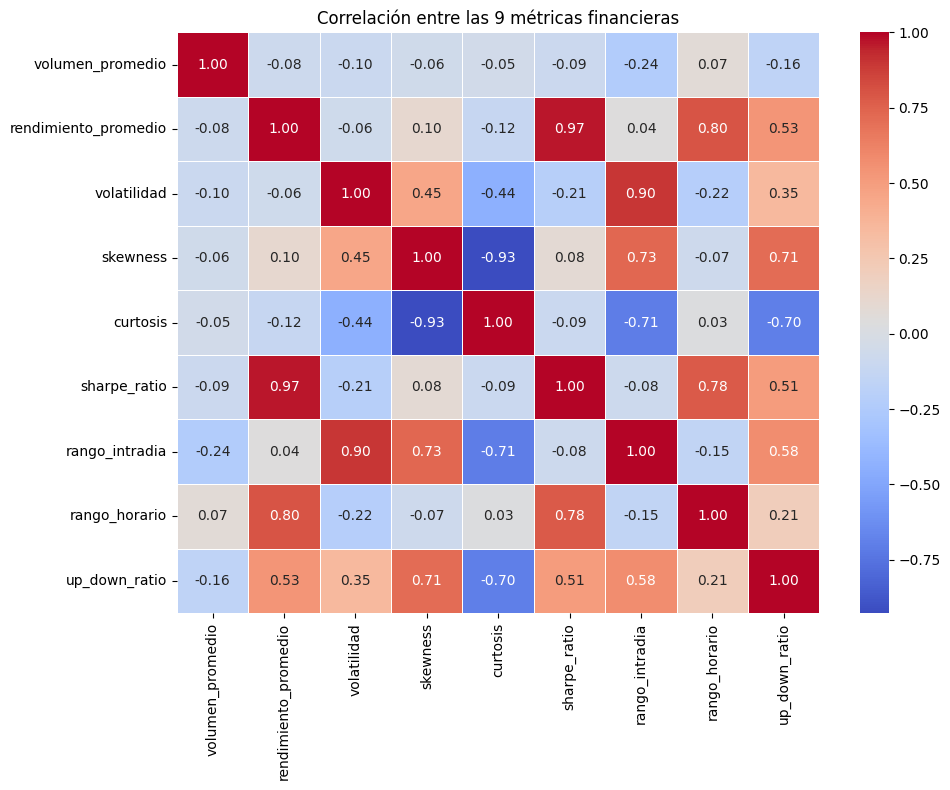

In [104]:
# Se obtiene la matriz de correlación entre las 9 métricas
# La correlación mide la relación lineal entre dos variables (-1 a 1)
# Correlación cercana a 1: cuando una sube, la otra también
# Correlación cercana a -1: cuando una sube, la otra baja
# Correlación cercana a 0: no hay relación lineal
matriz_correlacion = df_metricas.corr()

# Se visualiza con un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,       # Se imprimen los valores numéricos dentro de los cuadros
    cmap="coolwarm",  # Paleta de colores: azul (negativo) a rojo (positivo)
    fmt=".2f",        # Se muestran 2 decimales
    linewidths=0.5    # Líneas entre cuadros para mejor lectura
)
plt.title('Correlación entre las 9 métricas financieras')
plt.tight_layout()
plt.show()

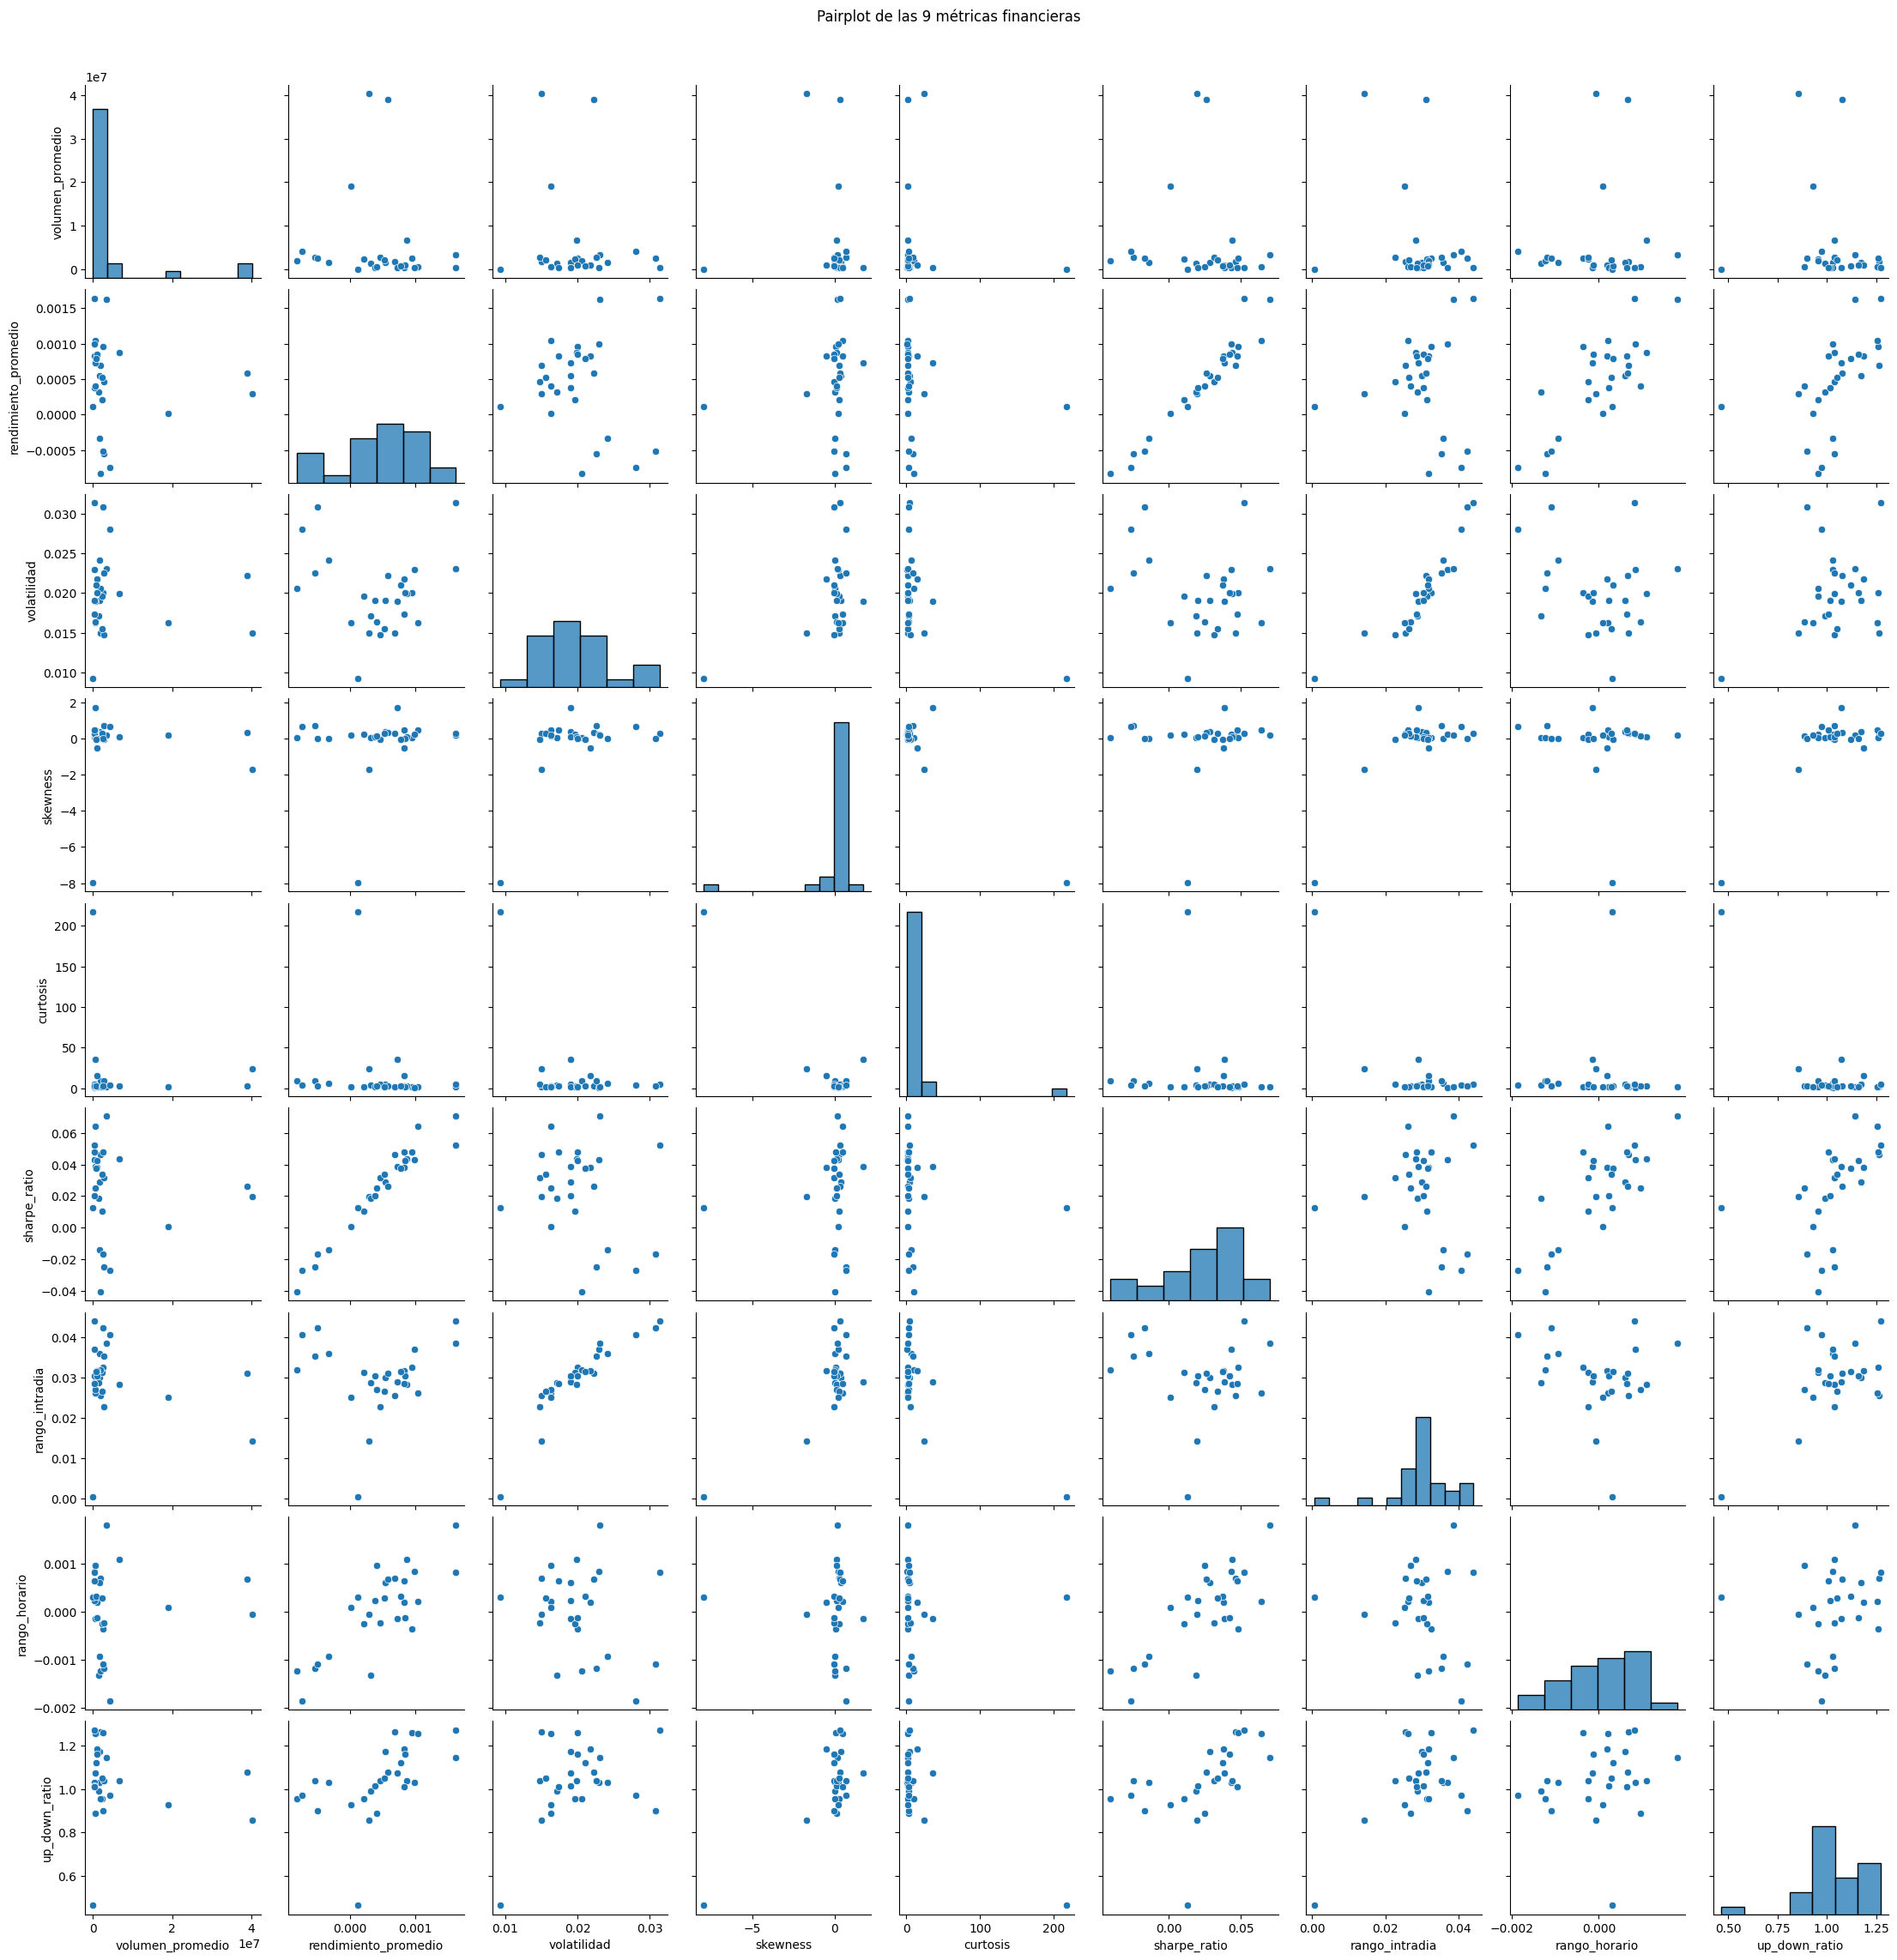

In [105]:
# Se grafica un pairplot para ver la distribución de cada métrica
# y las relaciones entre pares de métricas
# Como son 9 métricas, el pairplot tendrá 9x9 = 81 subgráficas
# La diagonal muestra la distribución de cada métrica individual
# Las celdas fuera de la diagonal muestran scatter plots entre pares
sns.pairplot(df_metricas)
plt.suptitle('Pairplot de las 9 métricas financieras', y=1.02)
plt.show()

## Paso 5: Escalado de variables

**¿Por qué escalar?** Los algoritmos de clustering (K-Means, DBSCAN) calculan distancias entre puntos. Si no escalamos, las variables con magnitudes grandes (como el volumen promedio, que puede estar en millones) dominarían completamente el cálculo de distancias, ignorando las variables con magnitudes pequeñas (como el rendimiento promedio, que está en fracciones de centésimas).

`StandardScaler` transforma cada variable para que tenga:
- **Media = 0**: Se le resta la media a cada valor
- **Desviación estándar = 1**: Se divide entre la desviación estándar

La fórmula es: $z = \frac{x - \mu}{\sigma}$

Después de escalar, todas las variables están en la misma escala y son comparables entre sí.

In [106]:
# Se eliminan las acciones que tengan valores NaN en alguna métrica
  # Esto puede pasar si una acción no tuvo datos suficientes en Yahoo Finance
print(f"Acciones ANTES de limpiar: {df_metricas.shape[0]}")
df_metricas = df_metricas.dropna()
print(f"Acciones DESPUÉS de limpiar: {df_metricas.shape[0]}")

  # Se define el escalador
scaler = StandardScaler()

  # Se aplica el escalado a las 9 columnas del DataFrame de métricas
X_scaled = scaler.fit_transform(df_metricas)

  # Se convierte de nuevo a DataFrame para facilitar la lectura
X_scaled = pd.DataFrame(X_scaled, columns=df_metricas.columns, index=df_metricas.index)

  # Se verifica que el escalado funcionó correctamente
print("\nMedia de cada columna (deberían ser ~0):")
print(X_scaled.mean().round(4))
print("\nDesviación estándar de cada columna (deberían ser ~1):")
print(X_scaled.std().round(4))

Acciones ANTES de limpiar: 29
Acciones DESPUÉS de limpiar: 28

Media de cada columna (deberían ser ~0):
volumen_promedio       -0.0
rendimiento_promedio    0.0
volatilidad             0.0
skewness                0.0
curtosis               -0.0
sharpe_ratio           -0.0
rango_intradia         -0.0
rango_horario           0.0
up_down_ratio           0.0
dtype: float64

Desviación estándar de cada columna (deberían ser ~1):
volumen_promedio        1.0184
rendimiento_promedio    1.0184
volatilidad             1.0184
skewness                1.0184
curtosis                1.0184
sharpe_ratio            1.0184
rango_intradia          1.0184
rango_horario           1.0184
up_down_ratio           1.0184
dtype: float64


In [107]:
# Se muestran los datos escalados para verificar que se ven razonables
X_scaled.head()

,volumen_promedio,rendimiento_promedio,volatilidad,skewness,curtosis,sharpe_ratio,rango_intradia,rango_horario,up_down_ratio
ticker,,,,,,,,,
AC,-0.323122,0.386962,-1.034486,0.254051,-0.282345,0.799868,-0.521735,0.791315,1.397682
ALPEKA,-0.336105,-1.274209,0.887092,0.088845,-0.174798,-1.379506,0.721714,-1.163612,-0.068060
ALSEA,-0.335045,0.148926,-0.185916,0.304802,-0.213208,0.163516,0.006265,0.677493,0.833295
AMXB,3.452058,-0.263126,-1.051109,-0.998277,0.274312,-0.168001,-1.892379,-0.108216,-1.160128
ASURB,-0.451656,0.449228,-0.197580,1.156586,0.559770,0.521377,-0.120753,-0.223015,0.195830


---

# Clustering

Ahora que tenemos una tabla limpia y escalada de 29 acciones x 9 métricas, aplicaremos tres algoritmos de clustering para intentar agrupar las acciones que se comportan de manera similar.

## ¿Qué es clustering?

Clustering (agrupamiento) es una técnica de **aprendizaje no supervisado**. A diferencia de la clasificación (supervisada), aquí **no sabemos de antemano** a qué grupo pertenece cada acción. El algoritmo descubre los grupos por sí mismo, basándose en la similitud entre las observaciones.

La idea es que las acciones dentro de un mismo cluster sean muy parecidas entre sí y muy diferentes a las acciones de otros clusters.

---

## Algoritmo 1: K-Means

**¿Cómo funciona K-Means?**
1. Se elige un número K de clusters
2. Se colocan K centroides aleatorios en el espacio de datos
3. Cada observación se asigna al centroide más cercano
4. Cada centroide se recalcula como el promedio de las observaciones asignadas a él
5. Se repiten los pasos 3 y 4 hasta que los centroides no se muevan más

**Ventaja**: Es rápido y sencillo de interpretar.

**Desventaja**: Requiere especificar K de antemano. Para elegirlo, usamos el **Método del Codo**.

### Método del Codo para elegir K

El **Método del Codo** consiste en entrenar K-Means con diferentes valores de K (por ejemplo, de 1 a 10) y graficar la **inercia** (WCSS: Within-Cluster Sum of Squares) para cada K.

La inercia mide la suma de las distancias al cuadrado de cada punto a su centroide más cercano. A medida que K aumenta, la inercia siempre disminuye (con K = N, cada punto es su propio cluster y la inercia es 0).

Se busca el "codo" de la curva: el punto donde agregar más clusters deja de reducir significativamente la inercia. Ese es el K óptimo.

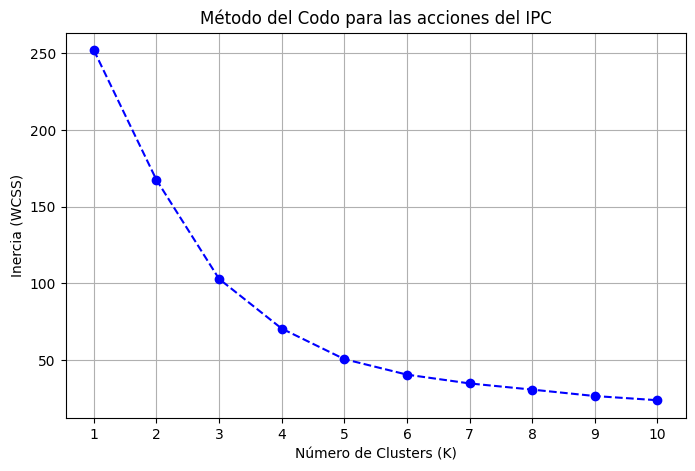

In [108]:
# Se calcula la inercia para diferentes valores de K (de 1 a 10)
inercia = []
K_range = range(1, 11)

for k in K_range:
    # Se entrena un modelo K-Means con k clusters
    # random_state=42: se fija la semilla para que el resultado sea reproducible
    # n_init=10: se ejecuta el algoritmo 10 veces con centroides iniciales diferentes
    #            y se queda con el mejor resultado (el de menor inercia)
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_scaled)

    # La inercia (WCSS) se almacena en el atributo .inertia_ del modelo entrenado
    inercia.append(modelo.inertia_)

# Se grafica el método del codo
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, marker='o', linestyle='--', color='b')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para las acciones del IPC')
plt.xticks(K_range)
plt.grid(True)
plt.show()

### Aplicación de K-Means con el K elegido

Basándose en el gráfico del codo, se selecciona un valor de K. Se probará con K=3 y K=4 para comparar.

In [109]:
# Se entrena K-Means con K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_3.fit(X_scaled)

# Se asigna a cada acción el cluster al que pertenece
# fit_predict() entrena y predice en un solo paso
df_metricas['cluster_kmeans_3'] = kmeans_3.fit_predict(X_scaled)

# Se muestran las acciones con su cluster asignado
# Esto nos dice qué acciones fueron agrupadas juntas
print("=== K-Means con K=3 ===")
for cluster_id in sorted(df_metricas['cluster_kmeans_3'].unique()):
    acciones_en_cluster = df_metricas[df_metricas['cluster_kmeans_3'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}: {acciones_en_cluster}")

=== K-Means con K=3 ===

Cluster 0: ['ALPEKA', 'CUERVO', 'ORBIA', 'TLEVISACPO', 'VOLARA']

Cluster 1: ['AC', 'ALSEA', 'ASURB', 'BBAJIOO', 'BIMBOA', 'BOLSAA', 'CEMEXCPO', 'CHDRAUIB', 'FEMSAUBD', 'GAPB', 'GCARSOA1', 'GCC', 'GENTERA', 'GFNORTEO', 'GRUMAB', 'PE&OLES', 'PINFRA', 'Q', 'RA', 'VESTA', 'WALMEX']

Cluster 2: ['AMXB', 'GNP']


In [110]:
# Se entrena K-Means con K = 4 para comparar
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_metricas['cluster_kmeans_4'] = kmeans_4.fit_predict(X_scaled)

print("=== K-Means con K=4 ===")
for cluster_id in sorted(df_metricas['cluster_kmeans_4'].unique()):
    acciones_en_cluster = df_metricas[df_metricas['cluster_kmeans_4'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}: {acciones_en_cluster}")

=== K-Means con K=4 ===

Cluster 0: ['ALPEKA', 'CUERVO', 'ORBIA', 'TLEVISACPO', 'VOLARA']

Cluster 1: ['AC', 'ALSEA', 'ASURB', 'BBAJIOO', 'BIMBOA', 'BOLSAA', 'CHDRAUIB', 'FEMSAUBD', 'GAPB', 'GCARSOA1', 'GCC', 'GENTERA', 'GFNORTEO', 'GRUMAB', 'PE&OLES', 'PINFRA', 'Q', 'RA', 'VESTA']

Cluster 2: ['AMXB', 'CEMEXCPO', 'WALMEX']

Cluster 3: ['GNP']


### Métricas de evaluación de K-Means

Para evaluar "qué tan buenos" son los clusters formados, se utilizan tres métricas:

| Métrica | ¿Qué mide? | ¿Qué valor es mejor? |
|---------|-------------|----------------------|
| **Silueta** | Qué tan parecido es un punto a su propio cluster vs. a otros clusters | Cercano a **1** (bien separados) |
| **Calinski-Harabasz** | Cociente entre dispersión entre clusters y dispersión dentro de clusters | **Mayor** es mejor |
| **Davies-Bouldin** | Similitud promedio entre cada cluster y su más parecido | **Menor** es mejor (cercano a 0) |

In [111]:
# Se calculan las métricas de evaluación para K-Means con K=3
print("=== Métricas K-Means con K=3 ===")
sil_3 = metrics.silhouette_score(X_scaled, df_metricas['cluster_kmeans_3'])
ch_3  = metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_kmeans_3'])
db_3  = metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_kmeans_3'])
print(f"Coeficiente de Silueta: {sil_3:.4f}")
print(f"Coeficiente de Calinski-Harabasz: {ch_3:.4f}")
print(f"Coeficiente de Davies-Bouldin: {db_3:.4f}")

# Se calculan las métricas de evaluación para K-Means con K=4
print("\n=== Métricas K-Means con K=4 ===")
sil_4 = metrics.silhouette_score(X_scaled, df_metricas['cluster_kmeans_4'])
ch_4  = metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_kmeans_4'])
db_4  = metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_kmeans_4'])
print(f"Coeficiente de Silueta: {sil_4:.4f}")
print(f"Coeficiente de Calinski-Harabasz: {ch_4:.4f}")
print(f"Coeficiente de Davies-Bouldin: {db_4:.4f}")

=== Métricas K-Means con K=3 ===
Coeficiente de Silueta: 0.4175
Coeficiente de Calinski-Harabasz: 15.1160
Coeficiente de Davies-Bouldin: 0.8409

=== Métricas K-Means con K=4 ===
Coeficiente de Silueta: 0.4293
Coeficiente de Calinski-Harabasz: 20.5890
Coeficiente de Davies-Bouldin: 0.6803


---

## Algoritmo 2: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**¿Cómo funciona DBSCAN?**

A diferencia de K-Means, DBSCAN **no requiere que se especifique el número de clusters**. En su lugar, busca "islas" de alta densidad de puntos.

Tiene dos parámetros clave:
- `eps`: Radio máximo de vecindad. Dos puntos son "vecinos" si su distancia es menor que `eps`.
- `min_samples`: Número mínimo de vecinos que necesita un punto para ser considerado un "punto núcleo".

**Tipos de puntos:**
- **Punto núcleo**: Tiene al menos `min_samples` vecinos dentro de un radio `eps`.
- **Punto frontera**: Está cerca de un punto núcleo pero no tiene suficientes vecinos propios.
- **Ruido (outlier)**: No es ni núcleo ni frontera. Se marca con la etiqueta **-1**.

**Ventaja**: Puede detectar outliers y no asume clusters de forma esférica.

**Desventaja**: Es muy sensible a `eps` y `min_samples`. Si `eps` es muy pequeño, casi todo es ruido. Si es muy grande, todo queda en un solo cluster.

In [112]:
# Se aplica DBSCAN con la mejor configuración encontrada en la exploración
# eps=1.5: radio de vecindad (en unidades estandarizadas, porque ya escalamos)
# min_samples=2: al menos 2 vecinos para ser punto núcleo
#   Se usa 2 porque con solo 28 acciones, un min_samples mayor deja demasiado ruido
#   La exploración de parámetros (celda siguiente) confirmó que esta configuración
#   da 3 clusters con solo 8 outliers, vs min_samples=3 que da 2 clusters con 10 outliers
dbscan = DBSCAN(eps=1.5, min_samples=2)

# Se obtienen las etiquetas de cluster
# Los puntos con etiqueta -1 son considerados RUIDO (outliers)
df_metricas['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# Se muestran los resultados
labels = dbscan.labels_
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido = list(labels).count(-1)

print(f"Número de clusters encontrados: {num_clusters}")
print(f"Número de puntos de ruido (outliers): {n_ruido} ({100*n_ruido/len(labels):.1f}%)")

print("\n=== Clusters DBSCAN ===")
for cluster_id in sorted(df_metricas['cluster_dbscan'].unique()):
    acciones_en_cluster = df_metricas[df_metricas['cluster_dbscan'] == cluster_id].index.tolist()
    etiqueta = f"Cluster {cluster_id}" if cluster_id != -1 else "RUIDO (outliers)"
    print(f"\n{etiqueta}: {acciones_en_cluster}")

Número de clusters encontrados: 3
Número de puntos de ruido (outliers): 8 (28.6%)

=== Clusters DBSCAN ===

RUIDO (outliers): ['AMXB', 'ASURB', 'BOLSAA', 'CEMEXCPO', 'GENTERA', 'GNP', 'PE&OLES', 'WALMEX']

Cluster 0: ['AC', 'ALSEA', 'BBAJIOO', 'BIMBOA', 'CHDRAUIB', 'FEMSAUBD', 'GAPB', 'GCARSOA1', 'GCC', 'GFNORTEO', 'GRUMAB', 'PINFRA', 'Q', 'RA', 'VESTA']

Cluster 1: ['ALPEKA', 'CUERVO', 'ORBIA']

Cluster 2: ['TLEVISACPO', 'VOLARA']


In [113]:
# Se calculan las métricas de evaluación para DBSCAN
# IMPORTANTE: Se deben excluir los puntos de ruido (-1) para calcular las métricas
# porque ruido NO es un cluster real
mask = labels != -1

if num_clusters > 1:
    sil_dbscan = metrics.silhouette_score(X_scaled[mask], labels[mask])
    ch_dbscan  = metrics.calinski_harabasz_score(X_scaled[mask], labels[mask])
    db_dbscan  = metrics.davies_bouldin_score(X_scaled[mask], labels[mask])
    print(f"Coeficiente de Silueta (sin ruido): {sil_dbscan:.4f}")
    print(f"Coeficiente de Calinski-Harabasz (sin ruido): {ch_dbscan:.4f}")
    print(f"Coeficiente de Davies-Bouldin (sin ruido): {db_dbscan:.4f}")
else:
    print("DBSCAN encontró 0 o 1 cluster. No se pueden calcular métricas de clustering.")
    print("Considere ajustar los parámetros eps y min_samples.")

Coeficiente de Silueta (sin ruido): 0.4909
Coeficiente de Calinski-Harabasz (sin ruido): 20.7538
Coeficiente de Davies-Bouldin (sin ruido): 0.6792


In [114]:
# Si DBSCAN no dio buenos resultados con la configuración anterior,
# se prueba con otro valor de eps
# Se experimenta con diferentes combinaciones de eps y min_samples
print("=== Exploración de parámetros DBSCAN ===\n")

for eps_val in [1.0, 1.5, 2.0, 2.5, 3.0]:
    for min_s in [2, 3, 4]:
        db_temp = DBSCAN(eps=eps_val, min_samples=min_s)
        labels_temp = db_temp.fit_predict(X_scaled)
        n_cl = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        n_noise = list(labels_temp).count(-1)
        print(f"eps={eps_val}, min_samples={min_s} -> {n_cl} clusters, {n_noise} ruido")

=== Exploración de parámetros DBSCAN ===

eps=1.0, min_samples=2 -> 4 clusters, 17 ruido
eps=1.0, min_samples=3 -> 1 clusters, 23 ruido
eps=1.0, min_samples=4 -> 1 clusters, 23 ruido
eps=1.5, min_samples=2 -> 3 clusters, 8 ruido


eps=1.5, min_samples=3 -> 2 clusters, 10 ruido
eps=1.5, min_samples=4 -> 1 clusters, 13 ruido
eps=2.0, min_samples=2 -> 1 clusters, 6 ruido
eps=2.0, min_samples=3 -> 1 clusters, 6 ruido
eps=2.0, min_samples=4 -> 1 clusters, 6 ruido
eps=2.5, min_samples=2 -> 1 clusters, 3 ruido
eps=2.5, min_samples=3 -> 1 clusters, 3 ruido
eps=2.5, min_samples=4 -> 1 clusters, 3 ruido
eps=3.0, min_samples=2 -> 1 clusters, 2 ruido
eps=3.0, min_samples=3 -> 1 clusters, 2 ruido
eps=3.0, min_samples=4 -> 1 clusters, 2 ruido


---

## Algoritmo 3: Clustering Jerárquico (Aglomerativo)

**¿Cómo funciona?**
1. Al inicio, cada observación es su propio cluster (29 clusters de tamaño 1)
2. Se buscan los dos clusters más cercanos y se fusionan en uno
3. Se repite el paso 2 hasta que todos los puntos estén en un solo cluster
4. Se "corta" la jerarquía a la altura deseada para obtener K clusters

La gran ventaja es que produce un **dendrograma**: un árbol que muestra cómo se van fusionando los clusters. Esto permite visualizar la estructura jerárquica de los datos y decidir visualmente cuántos clusters usar.

**Parámetros clave:**
- `n_clusters`: Número de clusters deseados (dónde "cortar" el dendrograma)
- `metric`: Tipo de distancia a usar (`euclidean`, `manhattan`, etc.)
- `linkage`: Criterio para medir la distancia entre clusters (`ward`, `complete`, `average`, `single`)
  - `ward`: Minimiza la varianza dentro de cada cluster (solo funciona con distancia euclidiana)
  - `average`: Usa el promedio de las distancias entre todos los pares de puntos

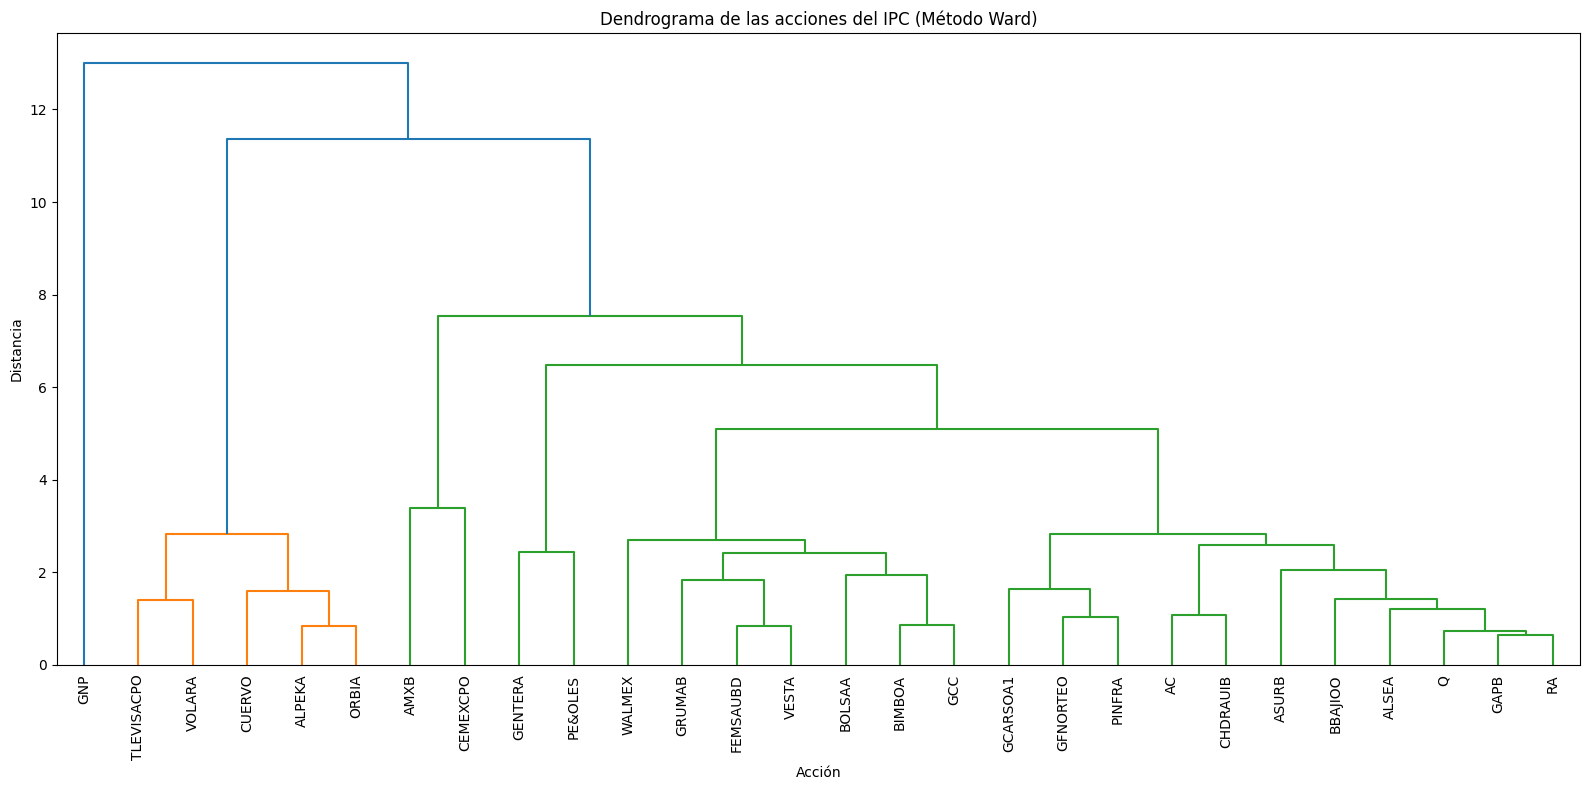

In [115]:
# Primero se construye el dendrograma para visualizar la jerarquía
# linkage() calcula la matriz de distancias jerárquicas
# method='ward' minimiza la varianza intra-cluster (buen default)
Z = linkage(X_scaled, method='ward')

# Se grafica el dendrograma
# El eje Y representa la distancia a la que se fusionan los clusters
# Cuanto más arriba se fusionan, más diferentes son
plt.figure(figsize=(16, 8))
dendrogram(
    Z,
    labels=df_metricas.index.tolist(),  # Se usan los tickers como etiquetas
    leaf_rotation=90,                    # Se rotan las etiquetas para que se lean mejor
    leaf_font_size=10                    # Tamaño de fuente de las etiquetas
)
plt.title('Dendrograma de las acciones del IPC (Método Ward)')
plt.xlabel('Acción')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

In [116]:
# Se aplica clustering jerárquico con 4 clusters (distancia euclidiana, método Ward)
# Se usan 4 clusters para ser consistentes con la decisión de K=4 en K-Means
# Ward con 3 clusters dejaba 22 de 28 acciones en un solo grupo, lo cual no es informativo
jerarquico_eucl = AgglomerativeClustering(n_clusters=4, linkage='ward')
df_metricas['cluster_jerarquico_ward'] = jerarquico_eucl.fit_predict(X_scaled)

print("=== Clustering Jerárquico (Ward, Euclidiana) con 4 clusters ===")
for cluster_id in sorted(df_metricas['cluster_jerarquico_ward'].unique()):
    acciones_en_cluster = df_metricas[df_metricas['cluster_jerarquico_ward'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}: {acciones_en_cluster}")

# Se calculan las métricas
sil_jw = metrics.silhouette_score(X_scaled, df_metricas['cluster_jerarquico_ward'])
ch_jw  = metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_jerarquico_ward'])
db_jw  = metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_jerarquico_ward'])
print(f"\nCoeficiente de Silueta: {sil_jw:.4f}")
print(f"Coeficiente de Calinski-Harabasz: {ch_jw:.4f}")
print(f"Coeficiente de Davies-Bouldin: {db_jw:.4f}")

=== Clustering Jerárquico (Ward, Euclidiana) con 4 clusters ===

Cluster 0: ['AC', 'ALSEA', 'ASURB', 'BBAJIOO', 'BIMBOA', 'BOLSAA', 'CHDRAUIB', 'FEMSAUBD', 'GAPB', 'GCARSOA1', 'GCC', 'GENTERA', 'GFNORTEO', 'GRUMAB', 'PE&OLES', 'PINFRA', 'Q', 'RA', 'VESTA', 'WALMEX']

Cluster 1: ['AMXB', 'CEMEXCPO']

Cluster 2: ['ALPEKA', 'CUERVO', 'ORBIA', 'TLEVISACPO', 'VOLARA']

Cluster 3: ['GNP']

Coeficiente de Silueta: 0.4308
Coeficiente de Calinski-Harabasz: 19.0562
Coeficiente de Davies-Bouldin: 0.6286


In [117]:
# Se aplica clustering jerárquico con distancia Manhattan (como K-Medians)
# La distancia Manhattan es más robusta a outliers que la euclidiana
# linkage='average' porque 'ward' solo funciona con distancia euclidiana
jerarquico_manh = AgglomerativeClustering(n_clusters=3, metric='manhattan', linkage='average')
df_metricas['cluster_jerarquico_manh'] = jerarquico_manh.fit_predict(X_scaled)

print("=== Clustering Jerárquico (Average, Manhattan) con 3 clusters ===")
for cluster_id in sorted(df_metricas['cluster_jerarquico_manh'].unique()):
    acciones_en_cluster = df_metricas[df_metricas['cluster_jerarquico_manh'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}: {acciones_en_cluster}")

# Se calculan las métricas
sil_jm = metrics.silhouette_score(X_scaled, df_metricas['cluster_jerarquico_manh'])
ch_jm  = metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_jerarquico_manh'])
db_jm  = metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_jerarquico_manh'])
print(f"\nCoeficiente de Silueta: {sil_jm:.4f}")
print(f"Coeficiente de Calinski-Harabasz: {ch_jm:.4f}")
print(f"Coeficiente de Davies-Bouldin: {db_jm:.4f}")

=== Clustering Jerárquico (Average, Manhattan) con 3 clusters ===

Cluster 0: ['AC', 'ALPEKA', 'ALSEA', 'ASURB', 'BBAJIOO', 'BIMBOA', 'BOLSAA', 'CEMEXCPO', 'CHDRAUIB', 'CUERVO', 'FEMSAUBD', 'GAPB', 'GCARSOA1', 'GCC', 'GENTERA', 'GFNORTEO', 'GRUMAB', 'ORBIA', 'PE&OLES', 'PINFRA', 'Q', 'RA', 'TLEVISACPO', 'VESTA', 'VOLARA', 'WALMEX']

Cluster 1: ['GNP']

Cluster 2: ['AMXB']

Coeficiente de Silueta: 0.3595
Coeficiente de Calinski-Harabasz: 9.0628
Coeficiente de Davies-Bouldin: 0.3799


---

## Paso 6: Visualización de clusters con PCA

Tenemos 9 métricas (9 dimensiones). No podemos graficar 9 dimensiones directamente. Usamos **PCA** (Análisis de Componentes Principales) para reducir de 9 dimensiones a 2, conservando la mayor cantidad de información posible.

Las dos primeras componentes principales (PC1 y PC2) capturan las direcciones de máxima variabilidad en los datos. Al graficar los puntos en este espacio reducido, podemos ver visualmente cómo se agrupan las acciones.

In [118]:
# Se aplica PCA para reducir de 9 dimensiones a 2
# n_components=2: queremos quedarnos con las 2 primeras componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Se convierte a DataFrame para facilitar la manipulación
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=df_metricas.index)

# Se muestra cuánta varianza explican las primeras 2 componentes
# Idealmente queremos que entre PC1 y PC2 expliquen al menos el 50-60% de la varianza
varianza_pc1 = pca.explained_variance_ratio_[0]
varianza_pc2 = pca.explained_variance_ratio_[1]
print(f"Varianza explicada por PC1: {varianza_pc1:.2%}")
print(f"Varianza explicada por PC2: {varianza_pc2:.2%}")
print(f"Varianza explicada total (PC1 + PC2): {varianza_pc1 + varianza_pc2:.2%}")

Varianza explicada por PC1: 41.54%
Varianza explicada por PC2: 32.25%
Varianza explicada total (PC1 + PC2): 73.79%


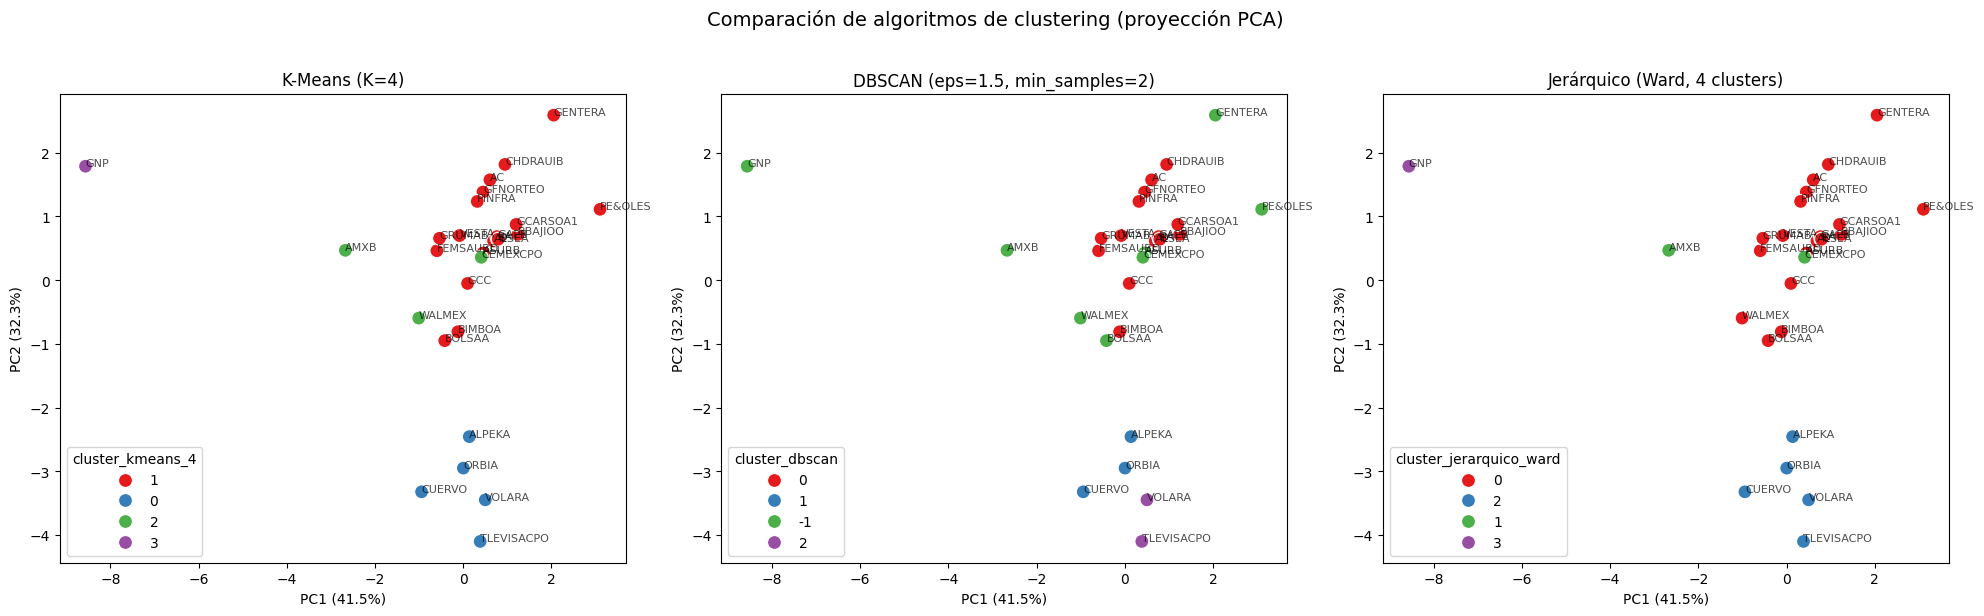

In [119]:
# Se crean 3 gráficas lado a lado para comparar visualmente los 3 algoritmos
# Cada gráfica muestra los mismos puntos (acciones en espacio PCA) pero coloreados
# según el cluster asignado por cada algoritmo

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Gráfica 1: K-Means (K=4) ---
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue=df_metricas['cluster_kmeans_4'].astype(str),
    palette='Set1', s=100, ax=axes[0]
)
# Se agrega el nombre de cada acción junto a su punto
for i, txt in enumerate(df_pca.index):
    axes[0].annotate(txt, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                     fontsize=8, alpha=0.7)
axes[0].set_title('K-Means (K=4)')
axes[0].set_xlabel(f'PC1 ({varianza_pc1:.1%})')
axes[0].set_ylabel(f'PC2 ({varianza_pc2:.1%})')

# --- Gráfica 2: DBSCAN ---
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue=df_metricas['cluster_dbscan'].astype(str),
    palette='Set1', s=100, ax=axes[1]
)
for i, txt in enumerate(df_pca.index):
    axes[1].annotate(txt, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                     fontsize=8, alpha=0.7)
axes[1].set_title('DBSCAN (eps=1.5, min_samples=2)')
axes[1].set_xlabel(f'PC1 ({varianza_pc1:.1%})')
axes[1].set_ylabel(f'PC2 ({varianza_pc2:.1%})')

# --- Gráfica 3: Jerárquico Ward ---
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2',
    hue=df_metricas['cluster_jerarquico_ward'].astype(str),
    palette='Set1', s=100, ax=axes[2]
)
for i, txt in enumerate(df_pca.index):
    axes[2].annotate(txt, (df_pca['PC1'].iloc[i], df_pca['PC2'].iloc[i]),
                     fontsize=8, alpha=0.7)
axes[2].set_title('Jerárquico (Ward, 4 clusters)')
axes[2].set_xlabel(f'PC1 ({varianza_pc1:.1%})')
axes[2].set_ylabel(f'PC2 ({varianza_pc2:.1%})')

plt.suptitle('Comparación de algoritmos de clustering (proyección PCA)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Paso 7: Perfil promedio de cada cluster

Para entender **qué hace diferente** a cada grupo de acciones, se calcula el promedio de las 9 métricas originales (sin escalar) dentro de cada cluster. Esto nos permite describir cada cluster en términos financieros concretos.

In [120]:
# Se seleccionan las 9 columnas originales (sin las columnas de clusters)
columnas_metricas = ['volumen_promedio', 'rendimiento_promedio', 'volatilidad',
                     'skewness', 'curtosis', 'sharpe_ratio',
                     'rango_intradia', 'rango_horario', 'up_down_ratio']

# Se calcula el perfil promedio de cada cluster (usando K-Means con K=4)
# groupby agrupa las filas por cluster y .mean() calcula el promedio de cada grupo
perfil_kmeans = df_metricas.groupby('cluster_kmeans_4')[columnas_metricas].mean()

print("=== Perfil promedio de cada cluster (K-Means K=4) ===")
perfil_kmeans

=== Perfil promedio de cada cluster (K-Means K=4) ===


,volumen_promedio,rendimiento_promedio,volatilidad,skewness,curtosis,sharpe_ratio,rango_intradia,rango_horario,up_down_ratio
cluster_kmeans_4,,,,,,,,,
0,2.619584e+06,-0.000596,0.025209,0.278196,6.336396,-0.024442,0.037272,-0.001259,0.978439
1,1.612479e+06,0.000774,0.019440,0.227544,4.971481,0.038949,0.030557,0.000327,1.101303
2,3.277386e+07,0.000296,0.017807,-0.395722,9.446754,0.015560,0.023529,0.000232,0.953955
3,1.010854e+03,0.000119,0.009277,-7.982987,217.408706,0.012830,0.000497,0.000300,0.463847


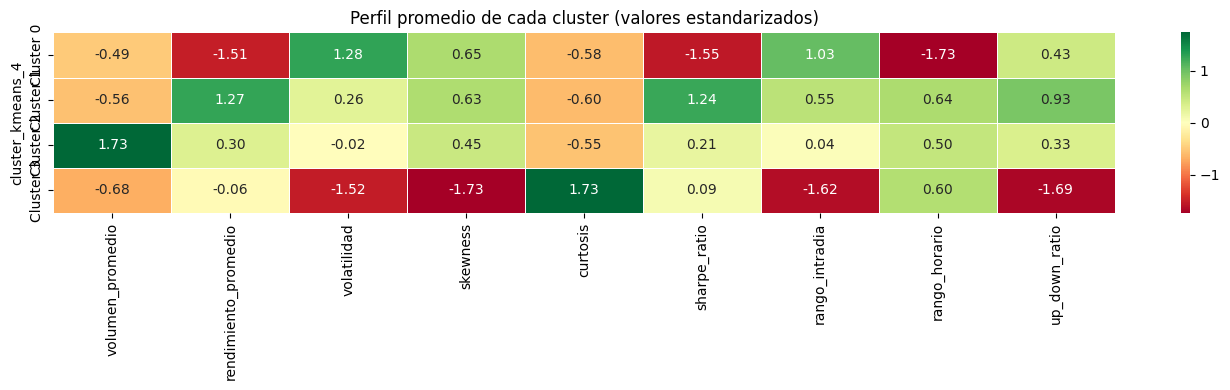

In [121]:
# Se visualiza el perfil de cada cluster con un heatmap
# Se escalan los perfiles para que sean comparables visualmente
perfil_escalado = pd.DataFrame(
    StandardScaler().fit_transform(perfil_kmeans),
    columns=columnas_metricas,
    index=perfil_kmeans.index
)

plt.figure(figsize=(14, 4))
sns.heatmap(
    perfil_escalado,
    annot=True,
    cmap='RdYlGn',  # Rojo = bajo, Verde = alto
    fmt='.2f',
    linewidths=0.5,
    yticklabels=[f'Cluster {i}' for i in perfil_kmeans.index]
)
plt.title('Perfil promedio de cada cluster (valores estandarizados)')
plt.tight_layout()
plt.show()

---

## Paso 8: ¿La ventana de tiempo tiene algún efecto?

Una pregunta clave del proyecto es si los clusters cambian al usar una ventana temporal diferente.

La intuición es que sí: las condiciones del mercado cambian. Una acción que fue volátil durante la pandemia (2020-2021) puede haberse estabilizado después. Los agrupamientos podrían reflejar condiciones de mercado temporales más que características permanentes de las empresas.

Para responder esta pregunta, repetiremos todo el análisis con una ventana temporal más corta: solo el último año (2025-2026).

In [122]:
# Se descargan datos con una ventana temporal más corta: solo el último año
fecha_inicio_corta = "2025-01-01"
fecha_final_corta = "2026-03-31"

datos_corto = yf.download(
    lista_tickers_ipc,
    start=fecha_inicio_corta,
    end=fecha_final_corta,
    group_by='ticker',
    auto_adjust=True,
    progress=False
)

print(f"Ventana corta: {fecha_inicio_corta} a {fecha_final_corta}")
print(f"Dimensiones: {datos_corto.shape}")

$ELEKTRA.MX: possibly delisted; no timezone found

1 Failed download:
['ELEKTRA.MX']: possibly delisted; no timezone found


Ventana corta: 2025-01-01 a 2026-03-31
Dimensiones: (311, 146)


In [123]:
# Se calculan las 9 métricas para la ventana corta
resultados_corto = []
for ticker in lista_tickers_ipc:
    try:
        metricas = calcular_metricas(datos_corto, ticker)
        resultados_corto.append(metricas)
    except Exception as e:
        print(f"No se pudo procesar {ticker}: {e}")

df_metricas_corto = pd.DataFrame(resultados_corto).set_index('ticker')

# Se eliminan acciones con NaN (mismo tratamiento que la ventana larga)
print(f"Acciones ANTES de limpiar: {df_metricas_corto.shape[0]}")
df_metricas_corto = df_metricas_corto.dropna()
print(f"Acciones DESPUÉS de limpiar: {df_metricas_corto.shape[0]}")

# Se escala
scaler_corto = StandardScaler()
X_scaled_corto = scaler_corto.fit_transform(df_metricas_corto)
X_scaled_corto = pd.DataFrame(X_scaled_corto, columns=df_metricas_corto.columns, index=df_metricas_corto.index)

# Se aplica K-Means con K=4 (consistente con la ventana larga)
kmeans_corto = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_metricas_corto['cluster_kmeans'] = kmeans_corto.fit_predict(X_scaled_corto)

print(f"\n=== K-Means K=4 (ventana CORTA: 2025-2026) ===")
for cluster_id in sorted(df_metricas_corto['cluster_kmeans'].unique()):
    acciones = df_metricas_corto[df_metricas_corto['cluster_kmeans'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}: {acciones}")

Acciones ANTES de limpiar: 29
Acciones DESPUÉS de limpiar: 28

=== K-Means K=4 (ventana CORTA: 2025-2026) ===

Cluster 0: ['ALPEKA', 'CHDRAUIB', 'CUERVO', 'VOLARA']

Cluster 1: ['AC', 'ALSEA', 'ASURB', 'BBAJIOO', 'BIMBOA', 'BOLSAA', 'FEMSAUBD', 'GAPB', 'GCARSOA1', 'GCC', 'GFNORTEO', 'GRUMAB', 'ORBIA', 'PINFRA', 'Q', 'RA', 'TLEVISACPO', 'VESTA', 'WALMEX']

Cluster 2: ['AMXB', 'CEMEXCPO', 'GENTERA', 'PE&OLES']

Cluster 3: ['GNP']


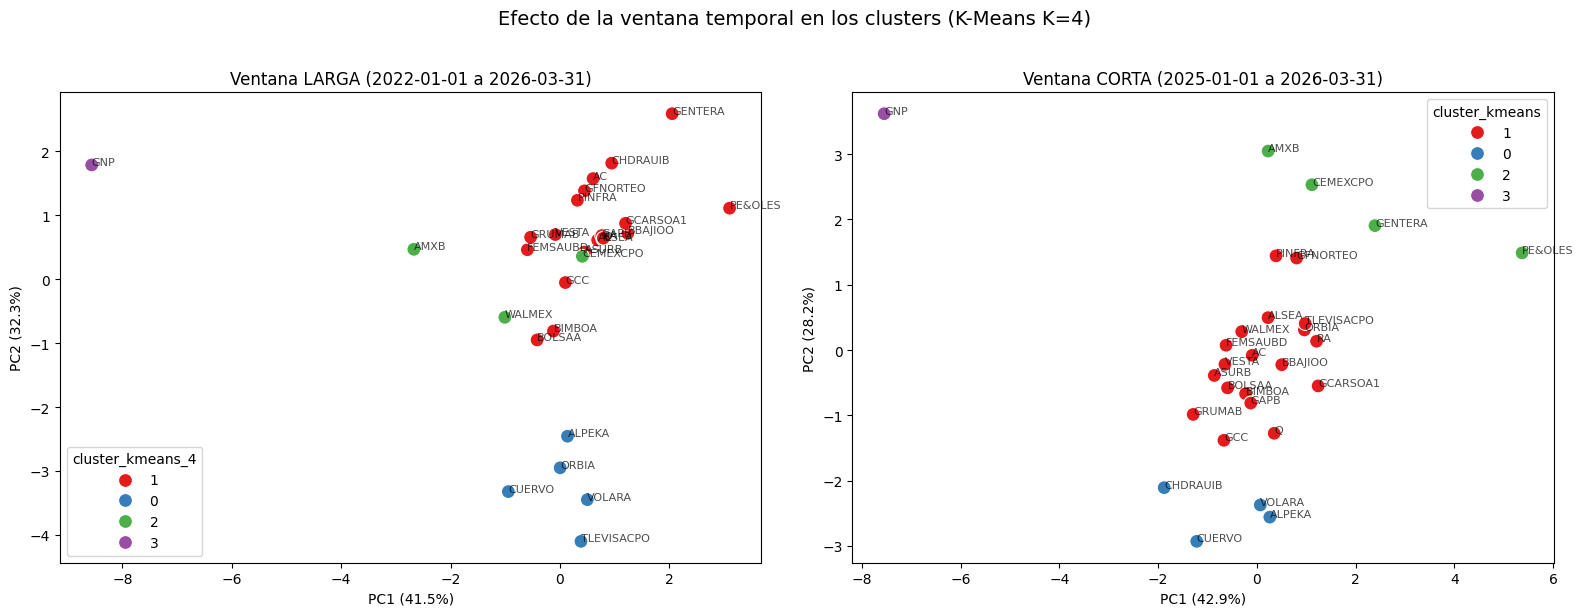

In [124]:
# Se comparan visualmente los clusters de ambas ventanas temporales
# Usando PCA para reducir a 2D en cada caso

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Ventana LARGA (2022-2026) ---
pca_largo = PCA(n_components=2)
X_pca_largo = pca_largo.fit_transform(X_scaled)
df_pca_largo = pd.DataFrame(X_pca_largo, columns=['PC1', 'PC2'], index=df_metricas.index)

sns.scatterplot(
    data=df_pca_largo, x='PC1', y='PC2',
    hue=df_metricas['cluster_kmeans_4'].astype(str),
    palette='Set1', s=100, ax=axes[0]
)
for i, txt in enumerate(df_pca_largo.index):
    axes[0].annotate(txt, (df_pca_largo['PC1'].iloc[i], df_pca_largo['PC2'].iloc[i]),
                     fontsize=8, alpha=0.7)
axes[0].set_title(f'Ventana LARGA ({fecha_inicio} a {fecha_final})')
axes[0].set_xlabel(f'PC1 ({pca_largo.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_largo.explained_variance_ratio_[1]:.1%})')

# --- Ventana CORTA (2025-2026) ---
pca_corto = PCA(n_components=2)
X_pca_corto = pca_corto.fit_transform(X_scaled_corto)
df_pca_corto = pd.DataFrame(X_pca_corto, columns=['PC1', 'PC2'], index=df_metricas_corto.index)

sns.scatterplot(
    data=df_pca_corto, x='PC1', y='PC2',
    hue=df_metricas_corto['cluster_kmeans'].astype(str),
    palette='Set1', s=100, ax=axes[1]
)
for i, txt in enumerate(df_pca_corto.index):
    axes[1].annotate(txt, (df_pca_corto['PC1'].iloc[i], df_pca_corto['PC2'].iloc[i]),
                     fontsize=8, alpha=0.7)
axes[1].set_title(f'Ventana CORTA ({fecha_inicio_corta} a {fecha_final_corta})')
axes[1].set_xlabel(f'PC1 ({pca_corto.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_corto.explained_variance_ratio_[1]:.1%})')

plt.suptitle('Efecto de la ventana temporal en los clusters (K-Means K=4)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [125]:
# Se comparan las métricas de clustering para ambas ventanas
print("=== Métricas de clustering: Ventana LARGA (2022-2026) ===")
print(f"Silueta: {metrics.silhouette_score(X_scaled, df_metricas['cluster_kmeans_4']):.4f}")
print(f"Calinski-Harabasz: {metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_kmeans_4']):.4f}")
print(f"Davies-Bouldin: {metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_kmeans_4']):.4f}")

print(f"\n=== Métricas de clustering: Ventana CORTA (2025-2026) ===")
print(f"Silueta: {metrics.silhouette_score(X_scaled_corto, df_metricas_corto['cluster_kmeans']):.4f}")
print(f"Calinski-Harabasz: {metrics.calinski_harabasz_score(X_scaled_corto, df_metricas_corto['cluster_kmeans']):.4f}")
print(f"Davies-Bouldin: {metrics.davies_bouldin_score(X_scaled_corto, df_metricas_corto['cluster_kmeans']):.4f}")

=== Métricas de clustering: Ventana LARGA (2022-2026) ===
Silueta: 0.4293
Calinski-Harabasz: 20.5890
Davies-Bouldin: 0.6803

=== Métricas de clustering: Ventana CORTA (2025-2026) ===
Silueta: 0.2570
Calinski-Harabasz: 12.1194
Davies-Bouldin: 0.9982


## Paso 9: Tabla resumen comparativa

Se consolidan todas las métricas de evaluación en una sola tabla para facilitar la comparación entre algoritmos.

In [126]:
# Se construye una tabla resumen con las métricas de todos los algoritmos
# Esto facilita la comparación directa
# NOTA: Se excluye Jerárquico Manhattan porque no logró separar las acciones
#       (26 de 28 quedaron en un solo cluster)

resumen = []

# K-Means K=3
resumen.append({
    'Algoritmo': 'K-Means (K=3)',
    'Silueta': metrics.silhouette_score(X_scaled, df_metricas['cluster_kmeans_3']),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_kmeans_3']),
    'Davies-Bouldin': metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_kmeans_3'])
})

# K-Means K=4
resumen.append({
    'Algoritmo': 'K-Means (K=4)',
    'Silueta': metrics.silhouette_score(X_scaled, df_metricas['cluster_kmeans_4']),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_kmeans_4']),
    'Davies-Bouldin': metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_kmeans_4'])
})

# Jerárquico Ward (4 clusters)
resumen.append({
    'Algoritmo': 'Jerárquico Ward (4 clusters)',
    'Silueta': metrics.silhouette_score(X_scaled, df_metricas['cluster_jerarquico_ward']),
    'Calinski-Harabasz': metrics.calinski_harabasz_score(X_scaled, df_metricas['cluster_jerarquico_ward']),
    'Davies-Bouldin': metrics.davies_bouldin_score(X_scaled, df_metricas['cluster_jerarquico_ward'])
})

# DBSCAN (solo puntos no-ruido)
if num_clusters > 1:
    mask_db = df_metricas['cluster_dbscan'] != -1
    resumen.append({
        'Algoritmo': f'DBSCAN (eps=1.5, min_s=2) [{num_clusters} clusters, {n_ruido} ruido]',
        'Silueta': metrics.silhouette_score(X_scaled[mask_db], df_metricas.loc[mask_db, 'cluster_dbscan']),
        'Calinski-Harabasz': metrics.calinski_harabasz_score(X_scaled[mask_db], df_metricas.loc[mask_db, 'cluster_dbscan']),
        'Davies-Bouldin': metrics.davies_bouldin_score(X_scaled[mask_db], df_metricas.loc[mask_db, 'cluster_dbscan'])
    })

df_resumen = pd.DataFrame(resumen).set_index('Algoritmo')
df_resumen

,Silueta,Calinski-Harabasz,Davies-Bouldin
Algoritmo,,,
K-Means (K=3),0.417545,15.116029,0.840929
K-Means (K=4),0.429282,20.589003,0.680266
Jerárquico Ward (4 clusters),0.430801,19.056236,0.628566
"DBSCAN (eps=1.5, min_s=2) [3 clusters, 8 ruido]",0.490943,20.753805,0.679228


---

## Interpretaciones

### 1. ¿Se pueden agrupar las acciones del IPC?

**Sí.** Los tres algoritmos de clustering coinciden en que las 28 acciones analizadas no se comportan todas igual. Se identifican al menos 4 perfiles distintos de comportamiento bursátil.

### 2. ¿Qué grupos se encontraron?

Usando K-Means con K=4 (el modelo con mejores métricas), se identificaron los siguientes clusters:

**Cluster 0 — Acciones volátiles con rendimiento negativo** (ALPEKA, CUERVO, ORBIA, TLEVISACPO, VOLARA):
- Son las acciones con **mayor volatilidad** (más riesgo).
- Tienen **rendimiento promedio negativo** (en promedio, perdieron valor durante el periodo).
- Su **Sharpe Ratio es negativo**, lo que significa que el riesgo asumido no se tradujo en ganancia.
- Presentan el **mayor rango intradía**, es decir, sus precios fluctúan mucho dentro de cada día de operación.

**Cluster 1 — El grupo principal** (AC, ALSEA, ASURB, BBAJIOO, BIMBOA, BOLSAA, CHDRAUIB, FEMSAUBD, GAPB, GCARSOA1, GCC, GENTERA, GFNORTEO, GRUMAB, PE&OLES, PINFRA, Q, RA, VESTA):
- Es el grupo más grande (19 acciones).
- Tienen **rendimiento positivo** y **volatilidad moderada**.
- Su **Sharpe Ratio es el más alto**, es decir, ofrecen la mejor relación rendimiento-riesgo.
- Son acciones de empresas consolidadas de distintos sectores (financiero, consumo, industrial, infraestructura).

**Cluster 2 — Acciones de alto volumen** (AMXB, CEMEXCPO, WALMEX):
- Se distinguen por tener un **volumen de operación significativamente mayor** que el resto.
- AMXB (América Móvil) tiene un volumen promedio de ~40 millones de acciones diarias, muy por encima del promedio.
- Su **curtosis es la más alta**, lo que indica mayor presencia de eventos extremos (días con movimientos inusuales).
- Corresponden a 3 de las empresas más grandes de México.

**Cluster 3 — GNP (aislada)**:
- GNP queda consistentemente sola en todos los algoritmos.
- Es una **aseguradora**, un sector muy diferente al resto del IPC (que es principalmente industrial, consumo y financiero).
- Tiene la **menor volatilidad** de todas las acciones y el **menor volumen de operación**.
- Su comportamiento bursátil es fundamentalmente distinto al de las demás.

### 3. ¿Los algoritmos coinciden?

Sí, de manera notable:

| Patrón | K-Means K=4 | DBSCAN | Jerárquico Ward |
|--------|-------------|--------|-----------------|
| ALPEKA, CUERVO, ORBIA juntas | Cluster 0 | Cluster 1 | Cluster 2 |
| GNP aislada | Cluster 3 (sola) | Ruido | Cluster 3 (sola) |
| AMXB en grupo especial | Cluster 2 | Ruido | Cluster 1 |
| Grupo principal (~19 acciones) | Cluster 1 | Cluster 0 | Cluster 0 |

DBSCAN además identificó a TLEVISACPO y VOLARA como un subgrupo separado de ALPEKA/CUERVO/ORBIA, y clasificó a varias acciones como ruido (outliers), lo cual sugiere que no todas las acciones encajan limpiamente en un grupo.

### 4. ¿Qué algoritmo funcionó mejor?

Según las métricas de evaluación:

| Algoritmo | Silueta (mayor=mejor) | Calinski-Harabasz (mayor=mejor) | Davies-Bouldin (menor=mejor) |
|-----------|----------------------|--------------------------------|------------------------------|
| K-Means K=4 | 0.43 | **20.59** | 0.68 |
| Jerárquico Ward | **0.43** | 19.06 | **0.63** |
| DBSCAN | **0.49** | 20.75 | 0.68 |

- **DBSCAN** tiene la mejor Silueta (0.49), pero a costa de dejar el 28.6% de las acciones como ruido.
- **K-Means K=4** y **Jerárquico Ward** dan resultados muy similares y cubren todas las acciones sin desperdiciar datos.
- El **Jerárquico Manhattan** no logró separar las acciones (26 de 28 en un solo cluster) y fue excluido de la comparación final.

En la práctica, **K-Means K=4 es la mejor opción** porque ofrece buenas métricas, cubre todas las acciones, y produce clusters interpretables financieramente.

### 5. ¿La ventana de tiempo tiene algún efecto?

**Sí, la ventana temporal afecta significativamente los resultados.**

| Métrica | Ventana LARGA (2022-2026) | Ventana CORTA (2025-2026) |
|---------|--------------------------|--------------------------|
| Silueta | 0.43 | 0.26 |
| Calinski-Harabasz | 20.59 | 12.12 |
| Davies-Bouldin | 0.68 | 1.00 |

La ventana corta produce **clusters de menor calidad** (Silueta cae de 0.43 a 0.26). Además, la composición de los clusters cambia:

- **ORBIA y TLEVISACPO** pasaron del cluster volátil al grupo principal (su comportamiento reciente es más estable).
- **GNP** se mantuvo aislada en ambas ventanas (su diferencia es estructural, no temporal).
- **GENTERA y PE&OLES** migraron al cluster de alto volumen en la ventana corta.

Esto sugiere que los agrupamientos con ventanas largas capturan patrones más estables y estructurales del mercado, mientras que las ventanas cortas reflejan condiciones coyunturales que pueden cambiar rápidamente.

### 6. Conclusión

Las acciones del IPC **sí se pueden agrupar** de manera consistente. Los clusters reflejan diferencias reales en volatilidad, volumen, rendimiento y riesgo. El análisis revela que el mercado mexicano tiene al menos 4 perfiles de comportamiento bursátil, y que la ventana temporal de observación influye en la estabilidad de estos agrupamientos.